# BAA10Y Adaptive Agent Test for default convariate + HOAS for 1-day horizon




In [5]:
import pandas as pd
from BAA10Y_forecasting.adaptive_agent.tuner import (
    resolve_covariate_series_ids,
)
from BAA10Y_forecasting import (
    SERIES_ID_HYOAS_PROXY_CHANGE,
    build_baa10y_multivariate_service,
)
CHECK_ORIGIN = pd.Timestamp(
    "2025-01-08"
).to_pydatetime()

CHECK_PANEL = "default_plus_hyoas"


CHECK_COVARIATES = (
    resolve_covariate_series_ids(
        CHECK_PANEL
    )
)

check_service = (
    build_baa10y_multivariate_service(
        windows=(1, 5, 21),
        include_covariates=True,
        covariate_series_ids=(
            CHECK_COVARIATES
        ),
        strict_covariates=True,
        start="2016-01-01",
        refresh=False,
    )
)

coverage_rows = []

for series_id in CHECK_COVARIATES:
    frame = check_service.get_series(
        series_id,
        as_of=CHECK_ORIGIN,
    )

    coverage_rows.append({
        "series_id": series_id,
        "n_rows": len(frame),
        "start": (
            frame["timestamp"].min()
            if not frame.empty
            else None
        ),
        "end": (
            frame["timestamp"].max()
            if not frame.empty
            else None
        ),
        "empty": frame.empty,
    })

COVARIATE_COVERAGE = pd.DataFrame(
    coverage_rows
)

display(COVARIATE_COVERAGE)

assert not COVARIATE_COVERAGE[
    "empty"
].any()

COMMON_START = COVARIATE_COVERAGE[
    "start"
].max()

COMMON_END = COVARIATE_COVERAGE[
    "end"
].min()

print("Common start:", COMMON_START)
print("Common end:", COMMON_END)

assert COMMON_START <= COMMON_END

assert (
    COMMON_END
    >= (
        pd.Timestamp(CHECK_ORIGIN)
        - pd.offsets.BDay(1)
    )
)

print(
    "PASS: the complete panel has "
    "a valid overlapping period."
)

,series_id,n_rows,start,end,empty
0,vix_level_l1b,2268,2016-01-05,2025-01-08,False
1,vix_log_ret_1b_l1b,2267,2016-01-06,2025-01-08,False
2,ust10y_level_l1b,16441,1962-01-03,2025-01-08,False
3,ust2y10y_spread_l1b,12681,1976-06-02,2025-01-08,False
4,fed_funds_level_l1b,18399,1954-07-02,2025-01-08,False
5,cpi_mom_logdiff_l1b,2344,2016-01-15,2025-01-08,False
6,unemployment_rate_l1b,2344,2016-01-15,2025-01-08,False
7,oil_log_ret_1b_l1b,10178,1986-01-06,2025-01-08,False
8,dollar_index_log_ret_1b_l1b,4961,2006-01-04,2025-01-08,False
9,nasdaq_log_ret_1b_l1b,2267,2016-01-06,2025-01-08,False


Common start: 2023-08-09 00:00:00
Common end: 2025-01-08 00:00:00
PASS: the complete panel has a valid overlapping period.


## 1. Setup and experiment configuration


In [1]:
from pathlib import Path
import json
import logging

import pandas as pd
import yaml
from IPython.display import display

from BAA10Y_forecasting.adaptive_agent.agent import (
    build_baa10y_adaptive_config,
)
from BAA10Y_forecasting.adaptive_agent.skill_tools import (
    build_baa10y_tuning_tools,
)
from BAA10Y_forecasting.adaptive_agent.tuner import (
    resolve_covariate_series_ids,
)
from BAA10Y_forecasting.predictors.benchmark_configs import (
    get_benchmark_config,
)


def find_repo_root() -> Path:
    """Find the agentic-forecasting repository root."""

    here = Path.cwd().resolve()

    for candidate in (here, *here.parents):
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "aieng-forecasting").is_dir()
        ):
            return candidate

    raise RuntimeError("Could not find repository root.")


def call_json_tool(tool_name: str, **kwargs) -> dict:
    """Call one registered adaptive-agent tool and parse its JSON response."""

    if tool_name not in TOOL_BY_NAME:
        raise KeyError(
            f"Unknown tool {tool_name!r}. "
            f"Available tools: {sorted(TOOL_BY_NAME)}"
        )

    payload = json.loads(
        TOOL_BY_NAME[tool_name](**kwargs)
    )

    if payload.get("status") == "error":
        raise RuntimeError(payload.get("message", payload))

    return payload


ROOT = find_repo_root()
BAA10Y_DIR = ROOT / "implementations" / "BAA10Y_forecasting"
SPEC_DIRECTORY = BAA10Y_DIR / "specs"

METHOD = "lightgbm"
HORIZON = 1
COVARIATE_PANEL = "default_plus_hyoas"
INITIAL_TRIALS = 6
TOTAL_TRIALS = 12

# Run each expensive stage separately.
RUN_LIVE_AGENT = True
RUN_LEARNING_REPORT = False
RUN_OUTER_VALIDATION = False
RUN_PROTECTED_EVAL = False

DEMO_RUN_ID = "lightgbm_h1_default_plus_hyoas_no_gold_v2"
STATE_PATH = (
    BAA10Y_DIR
    / "adaptive_agent"
    / "state"
    / DEMO_RUN_ID
    / "tuning_state.yaml"
)

STUDY_NAME = (
    f"baa10y_{METHOD}_{COVARIATE_PANEL}_"
    f"h{HORIZON}_tune_paired_2025"
)

TOOLS = build_baa10y_tuning_tools(state_path=STATE_PATH)
TOOL_BY_NAME = {tool.__name__: tool for tool in TOOLS}

logging.getLogger("LiteLLM").setLevel(logging.CRITICAL)
logging.getLogger("litellm").setLevel(logging.CRITICAL)

print("Repository:", ROOT)
print("State:", STATE_PATH)
print("Study:", STUDY_NAME)
print("Method:", METHOD)
print("Horizon:", HORIZON)
print("Covariate panel:", COVARIATE_PANEL)
print("Trial budget:", INITIAL_TRIALS, "->", TOTAL_TRIALS)


Repository: /home/coder/agentic-forecasting
State: /home/coder/agentic-forecasting/implementations/BAA10Y_forecasting/adaptive_agent/state/lightgbm_h1_default_plus_hyoas_no_gold_v2/tuning_state.yaml
Study: baa10y_lightgbm_default_plus_hyoas_h1_tune_paired_2025
Method: lightgbm
Horizon: 1
Covariate panel: default_plus_hyoas
Trial budget: 6 -> 12


In [7]:
BENCHMARK_PARAMETERS = get_benchmark_config(
    METHOD,
    COVARIATE_PANEL,
)

SEARCH_SPACE = call_json_tool(
    "get_search_space",
    method=METHOD,
)

EXPERIMENT_COVARIATES = resolve_covariate_series_ids(
    COVARIATE_PANEL
)

CURRENT_STATE = call_json_tool("get_tuning_state")
EXISTING_STUDY = next(
    (
        study
        for study in CURRENT_STATE["studies"]
        if study["study_name"] == STUDY_NAME
    ),
    None,
)

print("Search strategy:", SEARCH_SPACE["strategy"])
print("Existing study:", EXISTING_STUDY is not None)
print("Number of experiment covariates:", len(EXPERIMENT_COVARIATES))

print("\nMatching benchmark parameters:")
display(BENCHMARK_PARAMETERS)

print("\nApproved parameter space:")
display(SEARCH_SPACE["parameter_space"])

print("\nHYOAS experiment covariates:")
display(EXPERIMENT_COVARIATES)


Search strategy: optuna_tpe
Existing study: True
Number of experiment covariates: 12

Matching benchmark parameters:


{'lags': 5,
 'lags_past_covariates': 5,
 'num_samples': 100,
 'lgbm_kwargs': {'num_threads': 1,
  'n_jobs': 1,
  'verbosity': -1,
  'random_state': 42}}


Approved parameter space:


{'lags': [3, 5, 10, 21],
 'lags_past_covariates': [3, 5, 10, 21],
 'n_estimators': {'minimum': 50, 'maximum': 400, 'step': 50},
 'learning_rate': {'minimum': 0.02, 'maximum': 0.15, 'scale': 'log'},
 'tree_shapes': [{'max_depth': 3, 'num_leaves': 7},
  {'max_depth': 4, 'num_leaves': 15},
  {'max_depth': 6, 'num_leaves': 31},
  {'max_depth': -1, 'num_leaves': 15},
  {'max_depth': -1, 'num_leaves': 31}],
 'min_child_samples': [10, 20, 40],
 'reg_alpha_l1': {'minimum': 0.0, 'maximum': 2.0},
 'reg_lambda_l2': {'minimum': 0.0, 'maximum': 5.0},
 'subsample': [0.7, 0.85, 1.0],
 'colsample_bytree': [0.7, 0.85, 1.0]}


HYOAS experiment covariates:


['vix_level_l1b',
 'vix_log_ret_1b_l1b',
 'ust10y_level_l1b',
 'ust2y10y_spread_l1b',
 'fed_funds_level_l1b',
 'cpi_mom_logdiff_l1b',
 'unemployment_rate_l1b',
 'oil_log_ret_1b_l1b',
 'dollar_index_log_ret_1b_l1b',
 'nasdaq_log_ret_1b_l1b',
 'hyoas_observed_change_1b_bps_l1b',
 'hyoas_hyg_dgs3_proxy_change_1b_bps_l1b']

## 2. Confirm the separated tuning windows


In [8]:
from aieng.forecasting.evaluation import MultiTargetBacktestSpec


EXPERIMENT_SPECS = {
    "development": "baa10y_tune_development_2025.yaml",
    "inner_validation": "baa10y_tune_inner_validation_2025.yaml",
    "outer_validation": "baa10y_validate_2025.yaml",
}


def load_backtest_spec(filename: str) -> MultiTargetBacktestSpec:
    """Load one multi-target backtest specification."""

    with (SPEC_DIRECTORY / filename).open(encoding="utf-8") as file:
        return MultiTargetBacktestSpec.model_validate(
            yaml.safe_load(file)
        )


LOADED_SPECS = {
    name: load_backtest_spec(filename)
    for name, filename in EXPERIMENT_SPECS.items()
}

EVALUATION_PERIODS = pd.DataFrame(
    [
        {
            "period": name,
            "start": specification.start.date(),
            "end": specification.end.date(),
            "stride": specification.stride,
            "warmup": specification.warmup,
        }
        for name, specification in LOADED_SPECS.items()
    ]
)

display(EVALUATION_PERIODS)

assert (
    LOADED_SPECS["development"].end
    < LOADED_SPECS["inner_validation"].start
)
assert (
    LOADED_SPECS["inner_validation"].end
    < LOADED_SPECS["outer_validation"].start
)


,period,start,end,stride,warmup
0,development,2025-01-08,2025-04-02,5,250
1,inner_validation,2025-05-07,2025-08-06,5,250
2,outer_validation,2025-09-10,2025-12-17,5,250


## 3. Run the adaptive agent


In [9]:
LIVE_AGENT_PROMPT = f"""
Tune {METHOD} for the {HORIZON}-business-day BAA10Y forecast using
the {COVARIATE_PANEL} covariate panel and its matching fixed benchmark.

Run {INITIAL_TRIALS} broad trials, review paired development and
inner-validation diagnostics, choose one evidence-based focus action,
and continue to {TOTAL_TRIALS} total trials. Freeze only a robust,
non-overfitting candidate that improves both development and
inner-validation CRPS.

Do not access outer validation, eval_2026, reject or promote a model.
If no robust candidate exists, retain the benchmark and do not freeze
a worse candidate merely to complete the workflow.
""".strip()

print(LIVE_AGENT_PROMPT)


Tune lightgbm for the 1-business-day BAA10Y forecast using
the default_plus_hyoas covariate panel and its matching fixed benchmark.

Run 6 broad trials, review paired development and
inner-validation diagnostics, choose one evidence-based focus action,
and continue to 12 total trials. Freeze only a robust,
non-overfitting candidate that improves both development and
inner-validation CRPS.

Do not access outer validation, eval_2026, reject or promote a model.
If no robust candidate exists, retain the benchmark and do not freeze
a worse candidate merely to complete the workflow.


In [11]:
async def run_live_agent_with_trace(prompt: str):
    """Run the ADK adaptive agent and record every tool call."""

    from aieng.forecasting.methods.agentic import build_adk_agent
    from google.adk.runners import InMemoryRunner
    from google.genai import types as genai_types

    agent_config = build_baa10y_adaptive_config(
        state_path=STATE_PATH,
        max_output_tokens=4096,
    )
    live_agent = build_adk_agent(agent_config)

    app_name = "baa10y_lightgbm_h1_hyoas_test"
    user_id = "notebook04_hyoas_user"
    runner = InMemoryRunner(agent=live_agent, app_name=app_name)

    session = await runner.session_service.create_session(
        app_name=app_name,
        user_id=user_id,
    )

    message = genai_types.Content(
        role="user",
        parts=[genai_types.Part(text=prompt)],
    )

    tool_trace = []
    response_parts = []

    try:
        async for event in runner.run_async(
            user_id=user_id,
            session_id=session.id,
            new_message=message,
        ):
            content = getattr(event, "content", None)
            parts = getattr(content, "parts", None) or []

            for part in parts:
                function_call = getattr(part, "function_call", None)

                if function_call is not None:
                    tool_trace.append(
                        {
                            "tool": function_call.name,
                            "arguments": dict(
                                getattr(function_call, "args", None) or {}
                            ),
                        }
                    )

                text_value = getattr(part, "text", None)

                if event.is_final_response() and text_value:
                    response_parts.append(text_value)
    finally:
        await runner.close()

    return "\n".join(response_parts), tool_trace


In [12]:
if RUN_LIVE_AGENT:
    LIVE_AGENT_REPLY, LIVE_AGENT_TRACE = await run_live_agent_with_trace(
        LIVE_AGENT_PROMPT
    )

    print("Agent response:\n")
    print(LIVE_AGENT_REPLY or "No final response returned.")
    print("\nNumber of tool calls:", len(LIVE_AGENT_TRACE))
    display(pd.DataFrame(LIVE_AGENT_TRACE))
else:
    print(
        "Search not started. Set RUN_LIVE_AGENT = True in the setup "
        "cell and rerun this cell when ready."
    )


[I 2026-08-23 19:22:12,981] Using an existing study with name 'baa10y_lightgbm_default_plus_hyoas_h1_tune_paired_2025' instead of creating a new one.
[I 2026-08-23 19:23:44,328] Trial 1 finished with value: 1.5442396702058505 and parameters: {'lags': 5, 'lags_past_covariates': 21, 'tree_shape': 'unlimited_leaves15', 'subsample': 0.7, 'n_estimators': 150, 'learning_rate': 0.05757368425309993, 'min_child_samples': 40, 'reg_alpha': 0.27898772130408367, 'reg_lambda': 1.4607232426760908, 'colsample_bytree': 1.0}. Best is trial 1 with value: 1.5442396702058505.
[I 2026-08-23 19:25:40,285] Trial 2 finished with value: 1.5027794839540316 and parameters: {'lags': 10, 'lags_past_covariates': 21, 'tree_shape': 'depth3_leaves7', 'subsample': 1.0, 'n_estimators': 50, 'learning_rate': 0.12495137958834718, 'min_child_samples': 20, 'reg_alpha': 1.0401360423556216, 'reg_lambda': 2.7335513967163982, 'colsample_bytree': 0.85}. Best is trial 2 with value: 1.5027794839540316.
[I 2026-08-23 19:28:04,649] Tr

Agent response:

### Tuning Study Summary

* **Method:** `lightgbm`
* **Horizon:** 1 business day (`h1`)
* **Covariate Panel:** `default_plus_hyoas`
* **Search Strategy:** Optuna TPE with `reduce_complexity` focus
* **Completed Trial Count:** 12 trials (6 broad search + 6 focused search)
* **Matching Benchmark Development CRPS:** 2.17784
* **Matching Benchmark Inner-Validation CRPS:** 1.52871
* **Best Robust Candidate (Trial 7) Development CRPS:** 2.16948 (improvement of 0.38%)
* **Best Robust Candidate (Trial 7) Inner-Validation CRPS:** 1.43767 (improvement of 5.96%)
* **Best Robust Candidate (Trial 7) Generalization Gap:** -33.73%
* **Best Robust Candidate (Trial 7) Possible Overfitting Status:** `false`
* **Best Robust Candidate (Trial 7) Robust Status:** `true`
* **Selected Agent Action:** `reduce_complexity` followed by freezing Trial 7 as the robust finalist.
* **Evidence Supporting the Action:** 
  * The initial 6 broad search trials revealed that lower-complexity trees with `ma

,tool,arguments
0,get_tuning_state,{}
1,get_search_space,{'method': 'lightgbm'}
2,run_adaptive_search,"{'horizon': 1, 'reason': 'Initial 6 broad tria..."
3,get_search_diagnostics,{'study_name': 'baa10y_lightgbm_default_plus_h...
4,run_adaptive_search,"{'focus_action': 'reduce_complexity', 'max_tri..."
5,get_search_diagnostics,{'study_name': 'baa10y_lightgbm_default_plus_h...
6,freeze_search_candidate,"{'reason': 'Trial 7 is the best robust, non-ov..."


## 4. Inspect paired diagnostics and agent decisions


In [13]:
STATE_RESULT = call_json_tool("get_tuning_state")
STUDY_RECORD = next(
    (
        study
        for study in STATE_RESULT["studies"]
        if study["study_name"] == STUDY_NAME
    ),
    None,
)

if STUDY_RECORD is None:
    SEARCH_DIAGNOSTICS = None
    print("The study has not been created yet.")
else:
    assert STUDY_RECORD["method"] == METHOD
    assert STUDY_RECORD["horizon"] == HORIZON
    assert STUDY_RECORD["covariate_panel"] == COVARIATE_PANEL

    SEARCH_DIAGNOSTICS = call_json_tool(
        "get_search_diagnostics",
        study_name=STUDY_NAME,
    )

    print("Completed trials:", STUDY_RECORD["completed_trials"])
    print("Frozen:", STUDY_RECORD["search_frozen"])
    print("Best candidate:", STUDY_RECORD["best_candidate_id"])
    print("Validation decision:", STUDY_RECORD["validation_decision"])

    print("\nMatching benchmark:")
    display(SEARCH_DIAGNOSTICS["benchmark"])

    print("\nTrial diagnostics:")
    display(
        pd.DataFrame(SEARCH_DIAGNOSTICS["trial_diagnostics"])
        .sort_values("inner_validation_crps")
        .reset_index(drop=True)
    )

    print("\nRecorded agent actions:")
    display(pd.DataFrame(SEARCH_DIAGNOSTICS["agent_actions"]))


Completed trials: 12
Frozen: True
Best candidate: lightgbm_default_plus_hyoas_192966cd9ef8
Validation decision: pending_validation

Matching benchmark:


{'development_crps': 2.177842869440409,
 'inner_validation_crps': 1.5287127077488625,
 'generalization_gap_pct': -29.806106344960455}


Trial diagnostics:


,trial_number,candidate_id,development_crps,inner_validation_crps,development_improvement_pct,inner_validation_improvement_pct,generalization_gap_pct,possible_overfitting,robust_candidate,parameters
0,6,lightgbm_default_plus_hyoas_bbc6961eafd0,2.178782,1.434731,-0.043134,6.147761,-34.149863,False,False,"{'lags': 21, 'lags_past_covariates': 5, 'num_s..."
1,7,lightgbm_default_plus_hyoas_192966cd9ef8,2.169485,1.437665,0.383786,5.955827,-33.732408,False,True,"{'lags': 21, 'lags_past_covariates': 5, 'num_s..."
2,12,lightgbm_default_plus_hyoas_6b79ab34ad4a,2.173518,1.449677,0.198594,5.170081,-33.302731,False,True,"{'lags': 21, 'lags_past_covariates': 5, 'num_s..."
3,11,lightgbm_default_plus_hyoas_516e0d509e58,2.121254,1.476798,2.598394,3.395971,-30.380892,False,True,"{'lags': 21, 'lags_past_covariates': 10, 'num_..."
4,2,lightgbm_default_plus_hyoas_0c7f7bd98dbc,2.146950,1.502779,1.418511,1.696409,-30.003981,False,True,"{'lags': 10, 'lags_past_covariates': 21, 'num_..."
5,8,lightgbm_default_plus_hyoas_ded91eddd6ed,2.155586,1.509464,1.021989,1.259154,-29.974301,False,True,"{'lags': 21, 'lags_past_covariates': 5, 'num_s..."
6,10,lightgbm_default_plus_hyoas_c3f6b8b7da1c,2.282846,1.542292,-4.821444,-0.888286,-32.439954,False,False,"{'lags': 5, 'lags_past_covariates': 3, 'num_sa..."
7,1,lightgbm_default_plus_hyoas_1208f00dc562,2.143027,1.544240,1.598653,-1.015689,-27.941185,True,False,"{'lags': 5, 'lags_past_covariates': 21, 'num_s..."
8,9,lightgbm_default_plus_hyoas_b942710485a1,2.214846,1.553441,-1.699054,-1.617592,-29.862332,False,False,"{'lags': 21, 'lags_past_covariates': 5, 'num_s..."
9,5,lightgbm_default_plus_hyoas_47422fe32e3c,2.173440,1.564762,0.202175,-2.358164,-28.005264,True,False,"{'lags': 3, 'lags_past_covariates': 10, 'num_s..."



Recorded agent actions:


,action_type,focus_action,reason,completed_before,completed_after,requested_total_trials,candidate_id,development_crps,inner_validation_crps,generalization_gap_pct
0,parameter_search,broad_search,Initial 6 broad trials search for LightGBM def...,0.0,6.0,6.0,NaN,NaN,NaN,NaN
1,parameter_search,reduce_complexity,Focus on reduce_complexity since shallow trees...,6.0,12.0,12.0,NaN,NaN,NaN,NaN
2,freeze_candidate,NaN,"Trial 7 is the best robust, non-overfitting ca...",NaN,NaN,NaN,lightgbm_default_plus_hyoas_192966cd9ef8,2.169485,1.437665,-33.732408


In [15]:
RUN_LEARNING_REPORT = True
LEARNING_PROCEDURE_PROMPT = f"""
Explain the completed adaptive learning procedure for study:

{STUDY_NAME}

Call only get_tuning_state and get_search_diagnostics. Do not run
additional trials, validation, freezing, rejection or promotion.

Separate the matching benchmark, Optuna parameter proposals, paired
backtester metrics, agent focus decisions and persistent state. Include
a trial-by-trial table, explain which parameters helped or hurt, and state
whether a robust finalist was frozen. Do not claim that the LLM updated
its neural-network weights.
""".strip()

if RUN_LEARNING_REPORT:
    LEARNING_REPLY, LEARNING_TRACE = await run_live_agent_with_trace(
        LEARNING_PROCEDURE_PROMPT
    )
    print(LEARNING_REPLY)
    display(pd.DataFrame(LEARNING_TRACE))
else:
    print(
        "Optional report not run. Set RUN_LEARNING_REPORT = True "
        "to ask the agent to explain the completed search without "
        "changing it."
    )


This is an explanation of the completed adaptive learning procedure for the study: **`baa10y_lightgbm_default_plus_hyoas_h1_tune_paired_2025`**.

---

### 1. Persistent Study State
*   **Study Name:** `baa10y_lightgbm_default_plus_hyoas_h1_tune_paired_2025`
*   **Method:** `lightgbm`
*   **Horizon:** 1 business day (`h1`)
*   **Covariate Panel:** `default_plus_hyoas` (includes primary targets, default macro/past covariates, plus HYOAS panel)
*   **Tuning Framework:** Optuna TPE (`


,tool,arguments
0,get_tuning_state,{}
1,get_search_diagnostics,{'study_name': 'baa10y_lightgbm_default_plus_h...


## 5. Run independent outer validation


In [2]:
RUN_OUTER_VALIDATION = True
# Refresh state because the live agent may have frozen a finalist.
STATE_RESULT = call_json_tool("get_tuning_state")
STUDY_RECORD = next(
    (
        study
        for study in STATE_RESULT["studies"]
        if study["study_name"] == STUDY_NAME
    ),
    None,
)

READY_FOR_VALIDATION = bool(
    STUDY_RECORD
    and STUDY_RECORD["search_frozen"]
    and STUDY_RECORD["best_candidate_id"]
)

print("Ready for independent validation:", READY_FOR_VALIDATION)

if RUN_OUTER_VALIDATION:
    if not READY_FOR_VALIDATION:
        raise RuntimeError(
            "No robust frozen finalist is available for validation."
        )

    VALIDATION_RESULT = call_json_tool(
        "run_frozen_validation",
        study_name=STUDY_NAME,
        force_refresh=False,
    )
    display(VALIDATION_RESULT)
else:
    VALIDATION_RESULT = None
    print(
        "Outer validation not run. After confirming the frozen finalist, "
        "set RUN_OUTER_VALIDATION = True and rerun this cell."
    )


Ready for independent validation: True


{'status': 'success',
 'study_name': 'baa10y_lightgbm_default_plus_hyoas_h1_tune_paired_2025',
 'method': 'lightgbm',
 'horizon': 1,
 'covariate_panel': 'default_plus_hyoas',
 'experiment': 'validate_2025',
 'required_repeats': 1,
 'baseline': {'candidate_id': 'lightgbm_default_plus_hyoas_33bec5d722d1',
  'mean_crps': 1.124423427892224,
  'crps_std': 0.0,
  'scores': [1.124423427892224],
  'parameters': {'lags': 5,
   'lags_past_covariates': 5,
   'num_samples': 100,
   'lgbm_kwargs': {'num_threads': 1,
    'n_jobs': 1,
    'verbosity': -1,
    'random_state': 42}}},
 'candidate': {'candidate_id': 'lightgbm_default_plus_hyoas_192966cd9ef8',
  'mean_crps': 1.119451787515857,
  'crps_std': 0.0,
  'scores': [1.119451787515857],
  'parameters': {'lags': 21,
   'lags_past_covariates': 5,
   'num_samples': 100,
   'lgbm_kwargs': {'num_threads': 1,
    'n_jobs': 1,
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 200,
    'learning_rate': 0.020862337002259902,
    'max_depth':

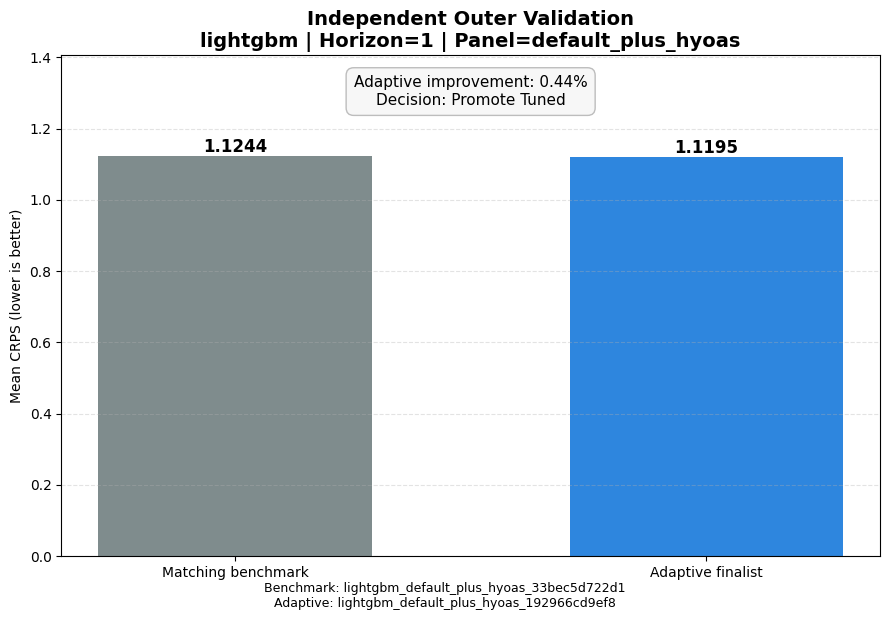

,parameter,matching_benchmark,adaptive_finalist,changed
0,colsample_bytree,LightGBM default,0.850000,True
1,lags,5,21.000000,True
2,learning_rate,LightGBM default,0.020862,True
3,max_depth,LightGBM default,3.000000,True
4,min_child_samples,LightGBM default,20.000000,True
5,n_estimators,LightGBM default,200.000000,True
6,num_leaves,LightGBM default,7.000000,True
7,reg_alpha,LightGBM default,1.922080,True
8,reg_lambda,LightGBM default,1.998104,True
9,subsample,LightGBM default,1.000000,True


In [3]:
import matplotlib.pyplot as plt
import pandas as pd


assert VALIDATION_RESULT is not None, (
    "Run the outer-validation cell first."
)

assert (
    VALIDATION_RESULT["status"]
    == "success"
), "Outer validation did not complete successfully."


OUTER_VALIDATION_DF = pd.DataFrame([
    {
        "model": "Matching benchmark",
        "candidate_id": (
            VALIDATION_RESULT[
                "baseline"
            ]["candidate_id"]
        ),
        "mean_crps": (
            VALIDATION_RESULT[
                "baseline"
            ]["mean_crps"]
        ),
    },
    {
        "model": "Adaptive finalist",
        "candidate_id": (
            VALIDATION_RESULT[
                "candidate"
            ]["candidate_id"]
        ),
        "mean_crps": (
            VALIDATION_RESULT[
                "candidate"
            ]["mean_crps"]
        ),
    },
])

improvement_pct = float(
    VALIDATION_RESULT[
        "improvement_pct"
    ]
)

decision = VALIDATION_RESULT[
    "decision"
]


fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.bar(
    OUTER_VALIDATION_DF["model"],
    OUTER_VALIDATION_DF["mean_crps"],
    color=[
        "#7F8C8D",
        "#2E86DE",
    ],
    width=0.58,
)

ax.set_title(
    "Independent Outer Validation\n"
    f"{METHOD} | Horizon={HORIZON} | "
    f"Panel={COVARIATE_PANEL}",
    fontsize=14,
    fontweight="bold",
)

ax.set_ylabel(
    "Mean CRPS (lower is better)"
)

ax.set_ylim(
    0,
    OUTER_VALIDATION_DF[
        "mean_crps"
    ].max() * 1.25,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35,
)

for bar, value in zip(
    bars,
    OUTER_VALIDATION_DF[
        "mean_crps"
    ],
    strict=True,
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

comparison_text = (
    f"Adaptive improvement: "
    f"{improvement_pct:.2f}%\n"
    f"Decision: "
    f"{decision.replace('_', ' ').title()}"
)

ax.text(
    0.5,
    0.96,
    comparison_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "#F7F7F7",
        "edgecolor": "#BDBDBD",
    },
)

benchmark_id = (
    VALIDATION_RESULT[
        "baseline"
    ]["candidate_id"]
)

adaptive_id = (
    VALIDATION_RESULT[
        "candidate"
    ]["candidate_id"]
)

fig.text(
    0.5,
    -0.02,
    (
        f"Benchmark: {benchmark_id}\n"
        f"Adaptive: {adaptive_id}"
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

plt.show()

def flatten_parameters(
    parameters: dict,
) -> dict:
    """Flatten predictor-level and LightGBM parameters."""

    flattened = {}

    for name, value in parameters.items():
        if (
            name == "lgbm_kwargs"
            and isinstance(value, dict)
        ):
            flattened.update(value)
        else:
            flattened[name] = value

    return flattened


# Prefer the exact parameters returned by validation.
# Use configuration/state as a fallback.
BASELINE_PARAMETERS = (
    VALIDATION_RESULT[
        "baseline"
    ].get("parameters")
    or get_benchmark_config(
        METHOD,
        COVARIATE_PANEL,
    )
)

ADAPTIVE_PARAMETERS = (
    VALIDATION_RESULT[
        "candidate"
    ].get("parameters")
    or STUDY_RECORD[
        "best_parameters"
    ]
)

baseline_flat = flatten_parameters(
    BASELINE_PARAMETERS
)

adaptive_flat = flatten_parameters(
    ADAPTIVE_PARAMETERS
)

parameter_names = sorted(
    set(baseline_flat)
    | set(adaptive_flat)
)

PARAMETER_COMPARISON = pd.DataFrame([
    {
        "parameter": parameter,
        "matching_benchmark": (
            baseline_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
        "adaptive_finalist": (
            adaptive_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
        "changed": (
            baseline_flat.get(
                parameter,
                "LightGBM default",
            )
            != adaptive_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
    }
    for parameter in parameter_names
])

PARAMETER_COMPARISON = (
    PARAMETER_COMPARISON.sort_values(
        [
            "changed",
            "parameter",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)




display(
    PARAMETER_COMPARISON
    
)